In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [58]:
X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_train = pd.read_csv("../data/processed/y_train_log.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test_log.csv").squeeze()

In [59]:
# X_train = pd.read_csv("../data/processed/X_train_processed_C.csv")
# X_test = pd.read_csv("../data/processed/X_test_processed_C.csv")
# y_train = pd.read_csv("../data/processed/y_train_log.csv").squeeze()
# y_test = pd.read_csv("../data/processed/y_test_log.csv").squeeze()

In [60]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5470, 45)
(1355, 45)
(5470,)
(1355,)


In [61]:
X_train

,Genre_Action,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,...,Decade_2010s,Decade_90s,Decade_pre-90s,Cat_Publisher_Publisher 1,Cat_Publisher_Publisher 2,Cat_Publisher_Publisher 3,Critic_Score,Critic_Count,User_Score,User_Count
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,58.0,26.0,5.4,77.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,67.0,14.0,8.4,28.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,58.0,13.0,6.8,4.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,90.0,47.0,8.9,634.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,68.0,25.0,8.1,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5465,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,65.0,17.0,7.3,44.0
5466,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,79.0,52.0,8.3,160.0
5467,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,78.0,33.0,8.1,63.0
5468,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,54.0,4.0,6.7,13.0


In [62]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_real = np.expm1(y_pred_rf)
y_test_real = np.expm1(y_test)

In [63]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest con log:\n")
print(f"MAE:  {mae_rf}")
print(f"MAE:  {mse_rf}")
print(f"RMSE: {rmse_rf}")
print(f"R²:   {r2_rf}")

Random Forest con log:

MAE:  0.20476209969709716
MAE:  0.09950649703080064
RMSE: 0.3154465042297991
R²:   0.5711032733918462


In [64]:
importances = rf.feature_importances_

In [65]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
44,User_Count,3.461289e-01
42,Critic_Count,1.135558e-01
41,Critic_Score,1.073177e-01
17,Platform_PC,1.027159e-01
43,User_Score,6.089369e-02
35,Decade_2010s,3.231674e-02
38,Cat_Publisher_Publisher 1,2.838235e-02
29,Rating_E,2.407063e-02
19,Platform_PS2,1.360306e-02
24,Platform_Wii,1.287023e-02


In [66]:
mae_lr = mean_absolute_error(y_test_real, y_pred_real)
mse_lr = mean_squared_error(y_test_real, y_pred_real)
rmse_lr = root_mean_squared_error(y_test_real, y_pred_real)
r2_lr = r2_score(y_test_real, y_pred_real)

print(f"Regresión Lineal sin log:\n")
print(f"MAE:  {mae_lr}")
print(f"MAE:  {mse_lr}")
print(f"RMSE: {rmse_lr}")
print(f"R²:   {r2_lr}")

Regresión Lineal sin log:

MAE:  0.5496780826283442
MAE:  6.890157403549707
RMSE: 2.6249109324984166
R²:   0.21361340797916462


In [67]:
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [68]:
reg_params = {
    "scaler" : [StandardScaler(), MinMaxScaler(), None],
}

In [69]:
svm_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "regressor": [SVR()],
    "regressor__C": [0.01,10,1000],
    "regressor__kernel": ['poly', 'rbf']
}

In [70]:
rf_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "regressor": [RandomForestRegressor()],
    "regressor__max_depth": [3, 5, 7, None],
    "regressor__n_estimators": [100, 200]
}

In [71]:
xgb_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "regressor": [XGBRegressor()],
    "regressor__max_depth": [3, 5, 7, None],
    "regressor__learning_rate": [0.05, 0.1, 0.2],
    "regressor__n_estimators": [100, 200]
}

In [72]:
knn_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "regressor": [KNeighborsRegressor()],
    "regressor__n_neighbors": [5, 8, 11, 14]
}

In [73]:
search = [
    reg_params,
    svm_params,
    rf_params,
    xgb_params,
    knn_params
]

In [74]:
reg_gs = GridSearchCV(pipe, search, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1, verbose=2)
reg_gs.fit(X_train, y_train)

Fitting 3 folds for each of 129 candidates, totalling 387 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'scaler': [StandardScaler(), MinMaxScaler(), ...]}, {'regressor': [SVR()], 'regressor__C': [0.01, 10, ...], 'regressor__kernel': ['poly', 'rbf'], 'scaler': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControl

In [88]:
print(reg_gs.best_score_)
print(reg_gs.best_estimator_)
print(reg_gs.best_params_)

-0.19109413362999317
Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                  

In [89]:
final_model = reg_gs.best_estimator_
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

In [90]:
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

In [94]:
mae = round(mean_absolute_error(y_test_real, y_pred_real), 3)
mse = round(mean_squared_error(y_test_real, y_pred_real), 3)
rmse = round(np.sqrt(mean_squared_error(y_test_real, y_pred_real)), 3)
r2 = round(r2_score(y_test_real, y_pred_real), 3)

print(f"MAE:  {mae} millones de unidades")
print(f"MSE:  {mse}")
print(f"RMSE: {rmse} millones de unidades")
print(f"R²:   {r2}")

MAE:  0.537 millones de unidades
MSE:  6.553
RMSE: 2.56 millones de unidades
R²:   0.252


In [79]:
import pickle

In [80]:
pickle.dump(final_model, open("../models/final_model.pkl", "wb"))

In [81]:
modelo_importado = pickle.load(open("../models/final_model.pkl", "rb"))
modelo_importado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [98]:
num_cols = ["Critic_Score", "Critic_Count", "User_Score", "User_Count"]
genre = ['Genre_Action', 'Genre_Adventure', 'Genre_Fighting', 'Genre_Misc',
       'Genre_Platform', 'Genre_Puzzle', 'Genre_Racing', 'Genre_Role-Playing',
       'Genre_Shooter', 'Genre_Simulation', 'Genre_Sports', 'Genre_Strategy']
platform = ['Platform_3DS', 'Platform_DC', 'Platform_DS', 'Platform_GBA',
       'Platform_GC', 'Platform_PC', 'Platform_PS', 'Platform_PS2',
       'Platform_PS3', 'Platform_PS4', 'Platform_PSP', 'Platform_PSV',
       'Platform_Wii', 'Platform_WiiU', 'Platform_X360', 'Platform_XB',
       'Platform_XOne']
rating = ['Rating_E', 'Rating_E10+', 'Rating_M', 'Rating_RP',
       'Rating_T']
decade = ['Decade_2000s', 'Decade_2010s', 'Decade_90s',
       'Decade_pre-90s']
cat_publisher = ['Cat_Publisher_Publisher 1',
       'Cat_Publisher_Publisher 2', 'Cat_Publisher_Publisher 3']

### DEMO

In [112]:
import random
sample = pd.DataFrame(0, index=[0], columns=X_train.columns)

sample['Critic_Score'] = random.randint(50, 100)
sample['User_Score'] = round(random.uniform(4.0, 9.5), 1)
sample["Critic_Count"] = random.randint(5, 100)
sample["User_Count"] = random.randint(5, 10000, )

sample[random.choice(genre)] = 1
sample[random.choice(platform)] = 1
sample[random.choice(rating)] = 1
sample[random.choice(decade)] = 1
sample[random.choice(cat_publisher)] = 1

print("Muestra generada:")
print(f"  Critic_Score: {sample['Critic_Score'].values[0]}")
print(f"  User_Score: {sample['User_Score'].values[0]}")
print(f"  Critic_Count: {sample['Critic_Count'].values[0]}")
print(f"  User_Count: {sample['User_Count'].values[0]}")
print(f"  Género: {[c for c in genre if sample[c].values[0] == 1]}")
print(f"  Plataforma: {[c for c in platform if sample[c].values[0] == 1]}")
print(f"  Rating: {[c for c in rating if sample[c].values[0] == 1]}")
print(f"  Década: {[c for c in decade if sample[c].values[0] == 1]}")
print(f"  Publisher: {[c for c in cat_publisher if sample[c].values[0] == 1]}")

prediccion_log = modelo_importado.predict(sample)
prediccion_real = np.expm1(prediccion_log)
print(f"\nVentas predichas: {prediccion_real[0]:.2f} millones de unidades")

Muestra generada:
  Critic_Score: 93
  User_Score: 5.6
  Critic_Count: 10
  User_Count: 7581
  Género: ['Genre_Simulation']
  Plataforma: ['Platform_GC']
  Rating: ['Rating_RP']
  Década: ['Decade_90s']
  Publisher: ['Cat_Publisher_Publisher 2']

Ventas predichas: 4.38 millones de unidades


### VISUALIZACIÓN DE RESULTADOS

In [92]:
y_pred = modelo_importado.predict(X_test)

y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

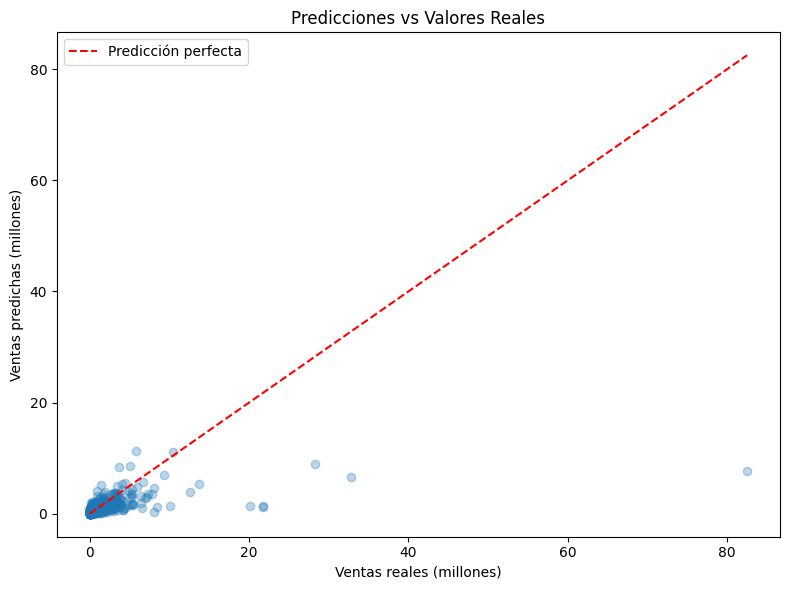

In [93]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3)
plt.plot([0, y_test_real.max()], [0, y_test_real.max()], 
         color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Ventas reales (millones)')
plt.ylabel('Ventas predichas (millones)')
plt.legend()
plt.tight_layout()
plt.show()

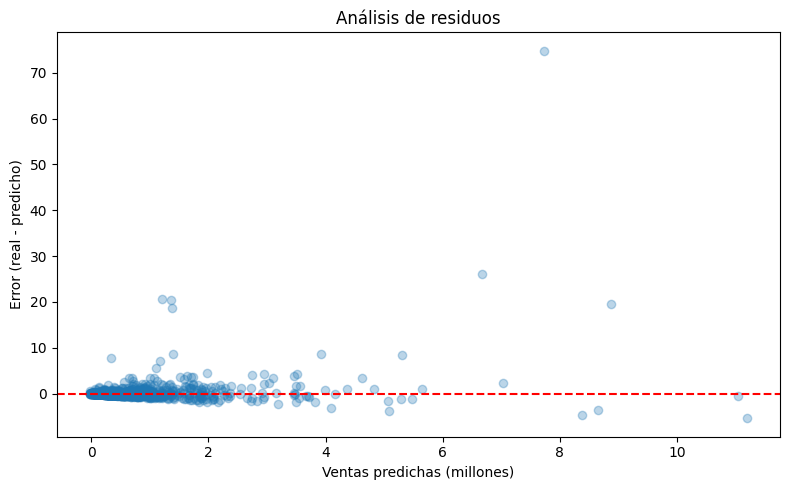

In [84]:
residuos = y_test_real - y_pred_real

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_real, residuos, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Análisis de residuos')
plt.xlabel('Ventas predichas (millones)')
plt.ylabel('Error (real - predicho)')
plt.tight_layout()
plt.show()

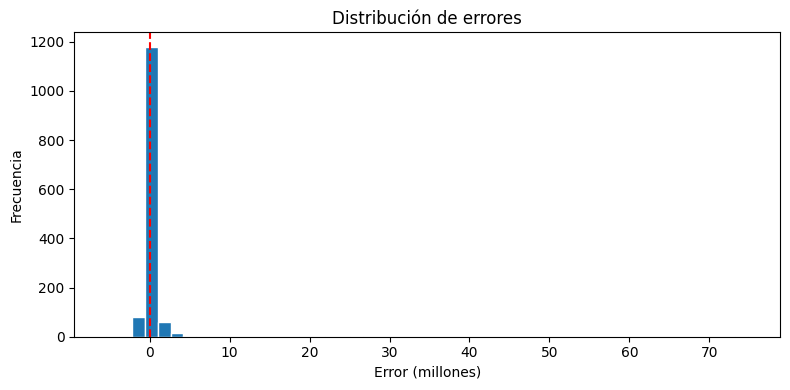

In [85]:
plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=50, edgecolor='white')
plt.title('Distribución de errores')
plt.xlabel('Error (millones)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

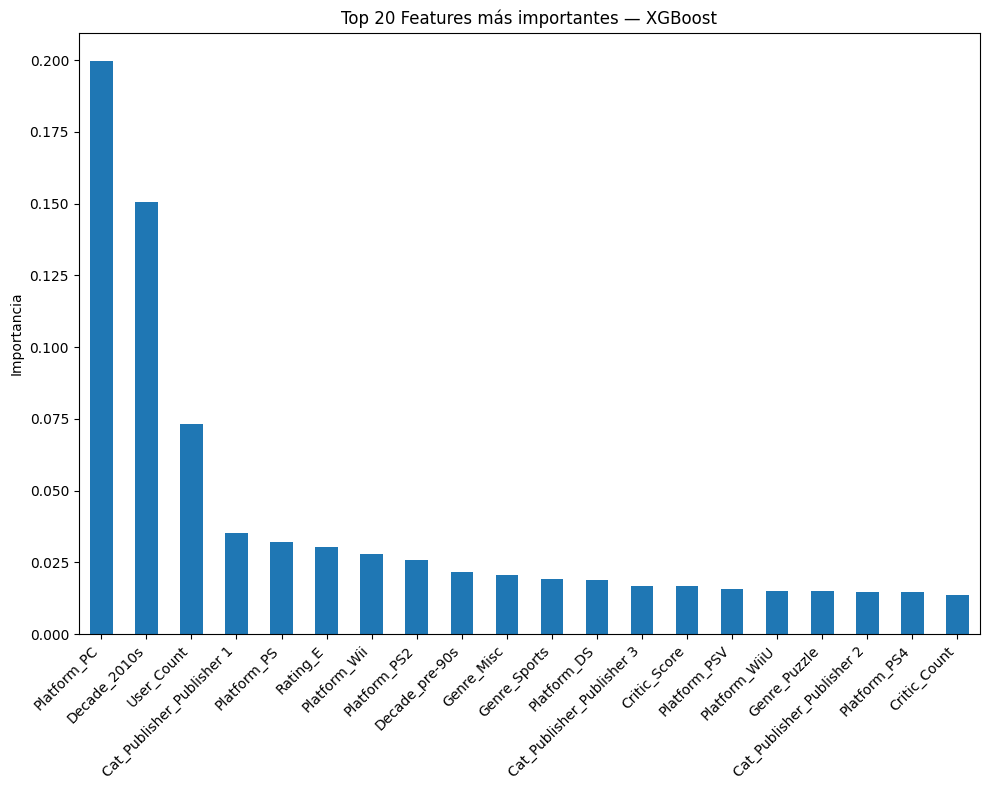

In [86]:
xgb_model = modelo_importado.named_steps["regressor"]

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index= X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feature_importance.head(20).plot(kind='bar')
plt.title('Top 20 Features más importantes — XGBoost')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [87]:
reg_rs = RandomizedSearchCV(pipe, search, cv=3, scoring="neg_mean_absolute_error",n_iter=100, n_jobs=-1, verbose=2)
reg_rs.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


KeyboardInterrupt: 

In [ ]:
print(reg_rs.best_score_)
print(reg_rs.best_estimator_)
print(reg_rs.best_params_)

-0.19109413362999317
Pipeline(steps=[('scaler', None),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              

In [ ]:
final_model2 = reg_rs.best_estimator_
final_model2.fit(X_train, y_train)
y_pred = final_model2.predict(X_test)

In [ ]:
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

In [ ]:
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print(f"MAE:  {mae} millones de unidades")
print(f"RMSE: {rmse} millones de unidades")
print(f"R²:   {r2}")

MAE:  0.537164437058246 millones de unidades
RMSE: 2.559795630005283 millones de unidades
R²:   0.25214475581050755


In [ ]:
pickle.dump(final_model2, open("../models/final_model2.pkl", "wb"))